# Modelo de velocidade OpenFWI com Deepwave

Esse notebook busca replicar a geometria de aquisição de um modelo de velocidade do datset OpenFWI usando o módulo Deepwave.

In [57]:
import torch
import matplotlib.pyplot as plt
import deepwave
from deepwave import scalar
import numpy as np
import matplotlib.pyplot as plt

import vis

In [58]:
device = torch.device('cpu')
print(device)

cpu


Buscamos replicar a geometria de aquisição descrita no [artigo do OpenFWI](https://arxiv.org/abs/2111.02926v6) para os conjuntos `FlatFault_A` e `FlatVel_A`.

<img src="geometria-de-aquisicao-vel-fault.png" alt="Geometria de aquisição" width="1000">

Usaremos essas informações na modelagem do Deepwave na tentativa de reproduzir os dados sísmicos.

# FlatVel_A

## Carregando FlatVel_A: data28

In [59]:
# load seismic data
seismic_data = np.load('openfwi-examples/FlatVel_A/data/data28.npy')
print('Seismic Data Loaded: data28')
print(f'Data shape: {seismic_data.shape}')

# load velocity map
velocity_map = np.load('openfwi-examples/FlatVel_A/model/model28.npy')
print('\nVelocity Map Loaded: model28')
print(f'Model shape: {velocity_map.shape}')

Seismic Data Loaded: data28
Data shape: (500, 5, 1000, 70)

Velocity Map Loaded: model28
Model shape: (500, 1, 70, 70)


Pelo shape dos dados, verificamos que:

---

1. Velocity Map (`model28`)

**Shape:** `(500, 1, 70, 70)`

Este é o modelo de velocidades da subsuperfície, que gera os dados sísmicos.

* **1:** Número de **canais (channels)**. Como a velocidade é uma propriedade escalar única para cada ponto do espaço, há apenas 1 canal.
* **70:** Dimensão espacial $X$ (largura do modelo).
* **70:** Dimensão espacial $Y$ (comprimento/profundidade do modelo).

> A tabela diz que o **Velocity Map Spatial Size** é de $0.7 \times 0.7\text{ km}^2$ ($700 \times 700\text{ m}$) e o **Grid Spacing** (espaçamento da malha) é de $10\text{ m}$. Dividindo o tamanho total pelo espaçamento ($\frac{700\text{ m}}{10\text{ m}}$), chegamos exatamente a **70 pontos de grade** por eixo.

---

2. Seismic Data (`data28`)

**Shape:** `(500, 5, 1000, 70)`

Estes são os dados sísmicos de reflexão registrados na superfície (os tiros e os traços recebidos).

* **5:** Número de **fontes sísmicas (shots)** por modelo.
> A tabela mostra que a **Source Line Length** é de $0.7\text{ km}$ ($700\text{ m}$) e o **Source Spacing** (distância entre os tiros) é de $140\text{ m}$. Se dividirmos $\frac{700}{140}$, temos exatamente **5 posições de tiro** ao longo da linha.


* **1000:** Número de **amostras temporais** por traço sísmico.
> O **Recorded Time** (tempo de gravação) é de $1\text{ s}$ e o **Time Spacing** (taxa de amostragem temporal) é de $0.001\text{ s}$ ($1\text{ ms}$). Dividindo o tempo total pelo intervalo ($\frac{1\text{ s}}{0.001\text{ s}}$), obtemos exatamente **1000 amostras de tempo**.


* **70:** Número de **receptores (geofones/hidrofones)** registrando cada tiro.
> A **Receiver Line Length** é de $0.7\text{ km}$ ($700\text{ m}$) e o **Receiver Line Spacing** é de $10\text{ m}$. Dividindo a linha pelo espaçamento ($\frac{700\text{ m}}{10\text{ m}}$), temos exatamente **70 receptores** dispostos na superfície.

Isso significa que, para cada um dos 500 cenários geológicos, você tem um experimento sísmico com **5 tiros diferentes**, onde cada tiro gerou um sismograma contendo **70 traços** (receptores), e cada traço tem **1000 pontos de tempo** de duração.

Podemos visualizar esses dados. Fixamos um modelo presente no arquivo selecionado para trabalhar.

In [60]:
sample = 0

In [61]:
def plot_velocity_model(model_tensor, sample_idx, path=None):
    """
    Plota o mapa de velocidade de um sample específico com os eixos baseados na geometria real.
    
    Parameters:
    - model_tensor: O tensor completo de velocidades (ex: shape 500, 1, 70, 70)
    - sample_idx: O índice do modelo que você deseja plotar (de 0 a 499)
    - path: Caminho para salvar a imagem (opcional)
    - rainbow_cmap: Colormap para o plot (padrão 'jet')
    """

    # Load colormap for velocity map visualization
    from matplotlib.colors import ListedColormap
    rainbow_cmap = ListedColormap(np.load('rainbow256.npy'))

    # 1. Extrai o sample e remove as dimensões extras para ficar 2D (70, 70)
    label = np.squeeze(model_tensor[sample_idx])
    
    plt.rcParams.update({'font.size': 16})
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    vmax, vmin = np.max(label), np.min(label)
    im = ax.matshow(label, cmap=rainbow_cmap, vmin=vmin, vmax=vmax)

    # Dimensões da tabela
    grid_spacing = 10       # 10 metros por pixel
    max_distance = 700      # 0.7 km = 700 metros
    tick_step_meters = 140  # Passo dos ticks em metros (ex: 0, 140, 280...)
    
    # Conversão de metros para índices da matriz (pixels)
    tick_step_pixels = tick_step_meters / grid_spacing # 140 / 10 = 14 pixels
    max_pixels = label.shape[0]                        # 70 pixels
    
    # Criando a lista de posições (pixels) e labels (metros)
    ticks_pixels = np.arange(0, max_pixels + 1, tick_step_pixels)
    ticks_meters = np.arange(0, max_distance + 1, tick_step_meters)
    
    # Configuração dos eixos
    ax.set_aspect(aspect=1)
    ax.set_xticks(ticks_pixels)
    ax.set_xticklabels(ticks_meters)
    ax.set_yticks(ticks_pixels)
    ax.set_yticklabels(ticks_meters)
    
    # Títulos e legendas
    ax.set_title('Distance (m)', y=1.08)
    ax.set_ylabel('Depth (m)', fontsize=18)

    fig.colorbar(im, ax=ax, shrink=1.0, label='Velocity (m/s)')
    
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f"Imagem salva em: {path}")
    
    plt.show()

Imagem salva em: outputs/FlatVel_A/model_plot_sample0.png


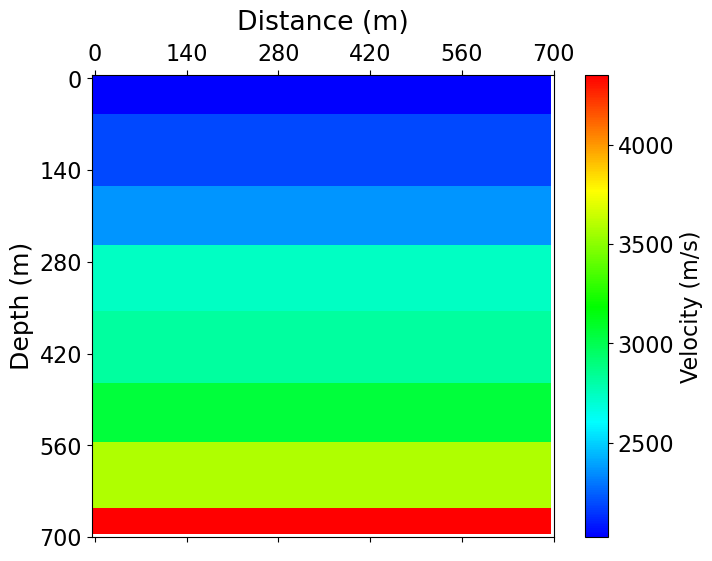

In [62]:
plot_velocity_model(velocity_map, sample, path=f"outputs/FlatVel_A/model_plot_sample{sample}.png")

In [63]:
def plot_5_shots(seismic_data, sample=0, path=None):
    # Se o dado vier com o shape completo (500, 5, 1000, 70), extraímos o sample
    if seismic_data.ndim == 4:
        data_sample = seismic_data[sample] # Shape resultante: (5, 1000, 70)
    else:
        data_sample = seismic_data
        
    nz, nx = data_sample[0].shape # 1000 amostras de tempo, 70 receptores
    
    plt.rcParams.update({'font.size': 11})
    
    # Criamos 1 linha e 5 colunas para os 5 tiros (shots)
    fig, axes = plt.subplots(1, 5, figsize=(18, 6))
    
    # --- Parâmetros baseados na tabela de aquisição ---
    # Eixo X: Receptores (0 a 700 metros, passo de 140m)
    dx = 10                  # Espaçamento dos receptores = 10m
    tick_step_x_meters = 140 # Passo do marcador em metros
    ticks_x_pixels = np.arange(0, nx + 1, tick_step_x_meters / dx)
    labels_x_meters = np.arange(0, 700 + 1, tick_step_x_meters)
    
    # Eixo Y: Tempo (0 a 1000 ms, passo de 200 ms)
    dt = 1                   # Espaçamento temporal = 1ms (0.001s)
    tick_step_y_ms = 200     # Passo do marcador em milissegundos
    ticks_y_pixels = np.arange(0, nz + 1, tick_step_y_ms / dt)
    labels_y_ms = np.arange(0, 1000 + 1, tick_step_y_ms)
    # -------------------------------------------------

    for i in range(5):
        ax = axes[i]
        shot_data = data_sample[i]
        
        # Escala de ganho (0.01 do valor máximo/mínimo)
        vmin, vmax = np.min(shot_data), np.max(shot_data)
        
        # 'aspect=auto' permite que o matplotlib estique a imagem para preencher o gráfico
        im = ax.matshow(shot_data, aspect='auto', cmap='gray', 
                        vmin=vmin * 0.01, vmax=vmax * 0.01)
        
        # Força o aspecto visual correto baseado nas proporções da matriz
        ax.set_aspect(aspect=nx/nz)
        
        # Configuração do Eixo X (Offset) para todos os plots
        ax.set_xticks(ticks_x_pixels)
        ax.set_xticklabels(labels_x_meters)
        ax.set_title(f'Shot {i+1}\nDistance (m)', y=1.08, fontsize=12, fontweight='bold')
        
        # Configuração do Eixo Y (Time) - Apenas no primeiro gráfico para evitar poluição visual
        ax.set_yticks(ticks_y_pixels)
        if i == 0:
            ax.set_yticklabels(labels_y_ms)
            ax.set_ylabel('Time (ms)', fontsize=13)
        else:
            ax.set_yticklabels([]) # Remove os números nos tiros subsequentes

    # Ajusta o espaçamento para a colorbar não sobrepor os gráficos
    fig.subplots_adjust(right=0.88, wspace=0.3)
    cbar_ax = fig.add_axes([0.91, 0.25, 0.015, 0.5]) # [esquerda, baixo, largura, altura]
    fig.colorbar(im, cax=cbar_ax, label='Amplitude')

    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f"Sismograma salvo em: {path}")

    plt.show()

Sismograma salvo em: outputs/FlatVel_A/seismic_plot_sample0.png


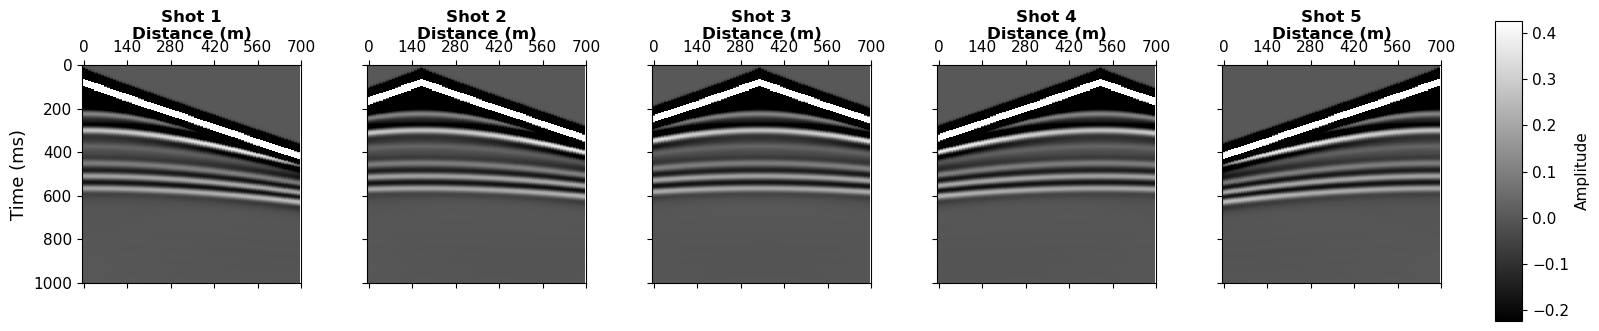

In [64]:
plot_5_shots(seismic_data, sample=0, path=f"outputs/FlatVel_A/seismic_plot_sample{sample}.png")

## Replicando `data` com Deepwave

In [65]:
# --- Parâmetros Sísmicos (Baseados no seu JSON) ---
dx = 10.0          # Espaçamento da grade (m) -> Alterado de 4.0 para 10.0 (conforme 'dx': 10)
dt = 1e-3          # Intervalo de tempo (s) -> Alterado para 0.001 (conforme 'dt': 1e-3)
nt = 1000          # Número de passos de tempo -> Alterado para 1000 (conforme 'nt': 1000)
peak_freq = 15     # Frequência central (Hz) -> Alterado para 15 (conforme 'f': 15)
peak_time = 1.0 / peak_freq  # Tempo de pico padrão para a Ricker (1/15 = 0.066s)
num_dims = 2       # Modelagem 2D

# --- Geometria de Aquisição (Baseados no seu JSON) ---
num_shots = 5                 # Número de fontes/tiros -> Alterado de 3 para 5 (conforme 'ns': 5)
num_sources_per_shot = 1      # 1 fonte por tiro
num_receivers_per_shot = 70   # Número de receptores -> Alterado de 384 para 70 (conforme 'ng': 70)

# Espaçamentos físicos em metros
source_spacing_m = 120        # Distância em metros entre os tiros (ajuste conforme seu modelo)
receiver_spacing_m = 10       # Distância em metros entre receptores (geralmente igual ao dx)
first_source_m = 100          # Posição X em metros da primeira fonte
first_receiver_m = 0          # Posição X em metros do primeiro receptor

# Profundidades em metros (Convertidas de 'sz': 10 e 'gz': 10 da grade -> 10 * 10m = 100m)
source_depth_m = 100          
receiver_depth_m = 100        

# --- Conversão de Metros para Índices da Grade (Essencial para o Deepwave) ---
source_spacing = int(source_spacing_m / dx)
receiver_spacing = int(receiver_spacing_m / dx)
first_source = int(first_source_m / dx)
first_receiver = int(first_receiver_m / dx)
source_depth = int(source_depth_m / dx)
receiver_depth = int(receiver_depth_m / dx)


# --- Criação dos Tensores de Posição ---

# source_locations (Dimensões: [num_shots, num_sources_per_shot, num_dims])
source_locations = torch.zeros(num_shots, num_sources_per_shot, num_dims,
                               dtype=torch.long, device=device)
source_locations[..., 1] = source_depth  # Define a profundidade Z fixa
# Calcula a posição X de cada tiro ao longo da grade
source_locations[:, 0, 0] = torch.arange(num_shots, device=device) * source_spacing + first_source

# receiver_locations (Dimensões: [num_shots, num_receivers_per_shot, num_dims])
receiver_locations = torch.zeros(num_shots, num_receivers_per_shot, num_dims,
                                 dtype=torch.long, device=device)
receiver_locations[..., 1] = receiver_depth  # Define a profundidade Z fixa
# Calcula a posição X de todos os receptores para todos os tiros
receiver_x = torch.arange(num_receivers_per_shot, device=device) * receiver_spacing + first_receiver
receiver_locations[:, :, 0] = receiver_x.repeat(num_shots, 1)


# --- Criando a Amplitude da Fonte (Ondaleta Ricker) ---

# O Deepwave gera a Ricker com formato [nt]. Precisamos expandir para [num_shots, num_sources, nt]
ricker_wavelet = deepwave.wavelets.ricker(peak_freq, nt, dt, peak_time)
source_amplitudes = (ricker_wavelet
                     .repeat(num_shots, num_sources_per_shot, 1)
                     .to(device))

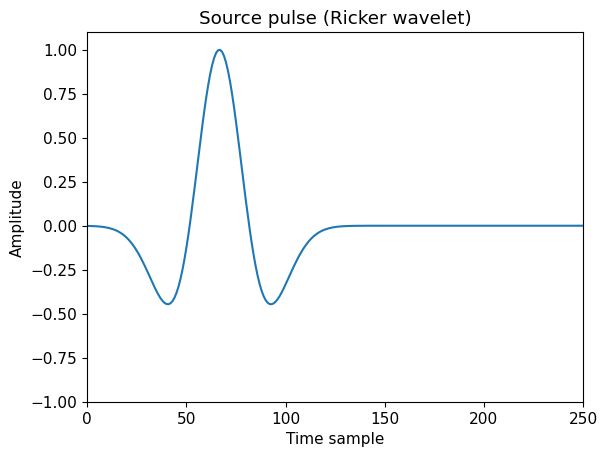

In [66]:
plt.plot(source_amplitudes.cpu().T[:, 0, 0])
plt.ylim(-1, 1+0.1)
plt.xlim(0, nt/4) 
plt.title('Source pulse (Ricker wavelet)')
plt.ylabel('Amplitude')
plt.xlabel('Time sample')
plt.show()

In [67]:
# --- 7. Convertendo o modelo de velocidade para Tensor ---
vel = velocity_map[sample, 0, :, :]
print(vel.shape)
v = torch.tensor(vel, dtype=torch.float32).T
print(v.shape)
print(source_locations)

(70, 70)
torch.Size([70, 70])
tensor([[[10, 10]],

        [[22, 10]],

        [[34, 10]],

        [[46, 10]],

        [[58, 10]]])


In [68]:
# --- 8. Propagação da Onda (Forward Modeling) ---
out = deepwave.scalar(
    v, 
    grid_spacing=dx,
    dt=dt,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    accuracy=4,
    pml_freq=peak_freq
)

# O dado sísmico gravado estará em out[-1]
data = out[-1]
print(f"Shape do dado simulado: {data.shape}")

Shape do dado simulado: torch.Size([5, 70, 1000])


In [69]:
# save modeled data to file
np.save(f'outputs/FlatVel_A/seismic_data_simulated_sample{sample}.npy', data.cpu().numpy())

Sismograma salvo em: outputs/FlatVel_A/seismic_plot_simulated_sample0.png


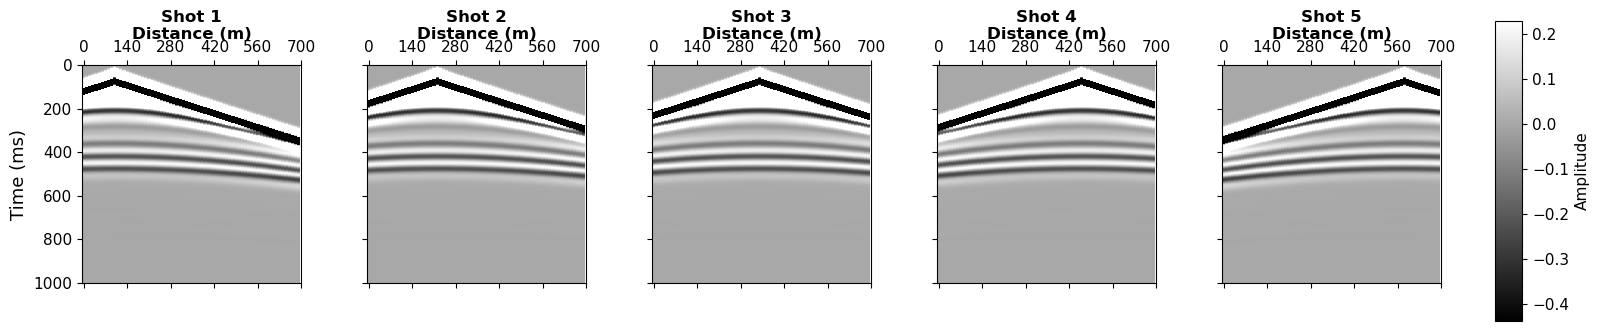

In [70]:
data = data.permute(0, 2, 1).cpu().numpy()
plot_5_shots(data, sample=0, path=f"outputs/FlatVel_A/seismic_plot_simulated_sample{sample}.png")

## Mitigando a diferença de amplitude

Ao comparar o dado sísmico original com o dado gerado, a discrepância mais evidente é na amplitude (representada pela escala de cinza). Isso pode ocorrer em razão da `source_amplitudes` gerada não ser compatível com a do dado adquirido originalmente.

Em uma inspeção do artigo referente ao dataset OpenFWI, podemos verificar informações sobre as velocidades e frequência dos dados:
>  The velocity values range from 1500 m/s to 4500 m/s, and the amplitude of seismic data is between −20 and 60 in “Vel Family”, “Fault Family” and “Style Family”. F

Apenas para testes, testaremos 3 valores de amplitude distribuidos no range de 20 a 60 especificado pelos autores para verificar se há melhora ou piora na amplitude dos dados gerados.

Sismograma salvo em: outputs/FlatVel_A/seismic_plot_simulated_sample0_freq25.0.png


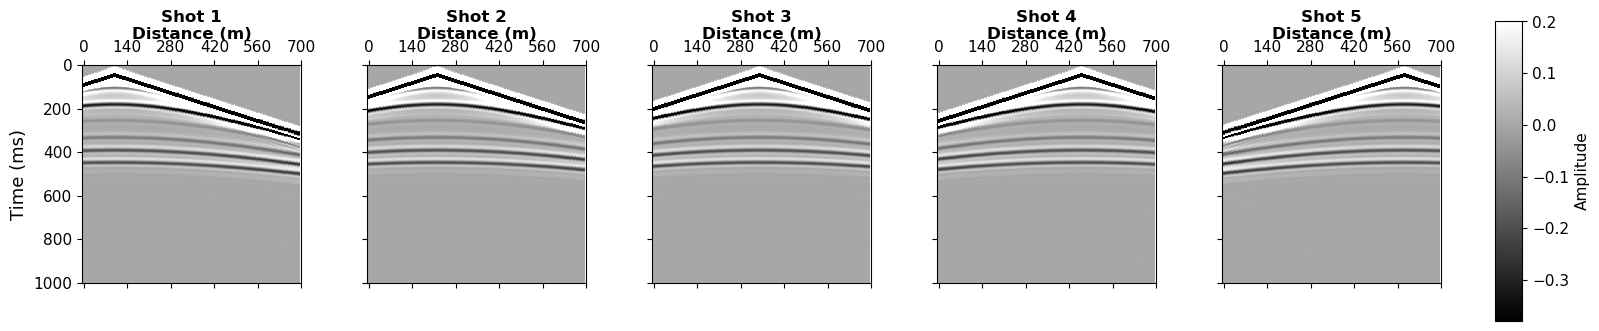

/home/al.bianca.abreu/.conda/envs/deepfwi-tf/lib/python3.12/site-packages/deepwave/common.py:1191: UserWarning: At least six grid cells per wavelength is recommended, but at a frequency of 45.0, a minimum non-zero velocity of 2025.0, and a grid cell spacing of 10.0, there are only 4.50.
  warnings.warn(


Sismograma salvo em: outputs/FlatVel_A/seismic_plot_simulated_sample0_freq45.0.png


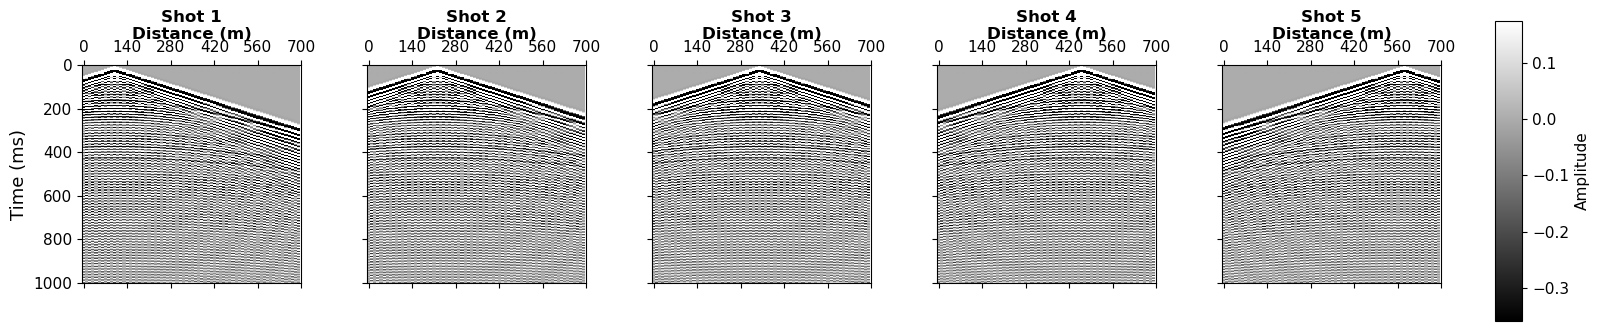

/home/al.bianca.abreu/.conda/envs/deepfwi-tf/lib/python3.12/site-packages/deepwave/common.py:1191: UserWarning: At least six grid cells per wavelength is recommended, but at a frequency of 60.0, a minimum non-zero velocity of 2025.0, and a grid cell spacing of 10.0, there are only 3.38.
  warnings.warn(


Sismograma salvo em: outputs/FlatVel_A/seismic_plot_simulated_sample0_freq60.0.png


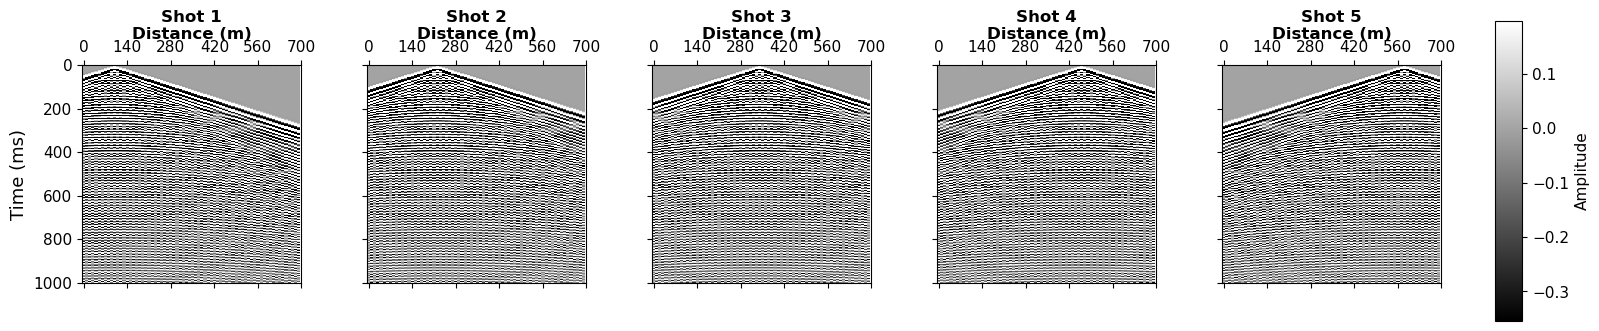

In [71]:
frequencies = [25.0, 45.0, 60.0]

for freq in frequencies:
    source_amplitudes = deepwave.wavelets.ricker(freq, nt, dt, 1.0/freq)
    source_amplitudes = source_amplitudes.repeat(num_shots, 1, 1)

    out = deepwave.scalar(
        v, 
        grid_spacing=dx,
        dt=dt,
        source_amplitudes=source_amplitudes,
        source_locations=source_locations,
        receiver_locations=receiver_locations,
        accuracy=4,
        pml_freq=freq
    )

    data = out[-1]
    
    data = data.permute(0, 2, 1).cpu().numpy()
    plot_5_shots(data, sample=0, path=f"outputs/FlatVel_A/seismic_plot_simulated_sample{sample}_freq{freq}.png")

## Métricas de comparação

### 1. MSE (Mean Squared Error — Erro Quadrático Médio)

O MSE calcula a média dos quadrados das diferenças de amplitude entre cada pixel (amostra de tempo e receptor) do dado original e do simulado.

* **O que avalia:** A discrepância geral de amplitude.
* **Comportamento:** Como ele eleva o erro ao quadrado, penaliza de forma muito severa **grandes erros**. Se uma reflexão forte aparecer no sismograma simulado numa posição onde não deveria existir nada, o MSE subirá drasticamente.
* **Ideal:** O mais próximo possível de **0**.

### 2. MAE (Mean Absolute Error — Erro Absoluto Médio)

O MAE calcula a média das diferenças absolutas (sem elevar ao quadrado) entre as amplitudes dos dois sismogramas.

* **O que avalia:** O erro médio contínuo nas amplitudes.
* **Comportamento:** É mais linear e "robusto" a discrepâncias extremas isoladas do que o MSE. Dá uma noção real de quão afastadas, em média, estão as amplitudes da simulação em relação ao dado original ao longo de todo o traço sísmico.
* **Ideal:** O mais próximo possível de **0**.

### 3. Correlação Cruzada Normalizada (Cross-Correlation)

Esta métrica mede o grau de semelhança e sincronia entre as formas de onda, traço por traço (geofone por geofone), independentemente da escala de energia absoluta.

* **O que avalia:** A **fase** e a **cinemática** (tempo de trânsito) das ondas.
* **Comportamento:** Varia estritamente entre **-1 e 1**. Se o valor for próximo de **1**, significa que as hipérboles de reflexão e as primeiras quebras chegam exatamente nos mesmos milissegundos nos dois sismogramas. É a métrica geofísica mais confiável para validar a geometria e a física da propagação.
* **Ideal:** O mais próximo possível de **1.0**.

### 4. SSIM (Structural Similarity Index — Índice de Similaridade Estrutural)

Diferente das métricas pixel a pixel, o SSIM foi desenhado originalmente para visão computacional. Ele analisa janelas locais da imagem e compara três fatores: luminância (amplitude média), contraste (variância) e estrutura (textura).

* **O que avalia:** A continuidade estrutural dos refletores e as texturas visuais.
* **Comportamento:** Varia entre **-1 e 1** (frequentemente normalizado entre 0 e 1). Na sísmica, ele é excelente porque avalia se a curvatura e a inclinação das hipérboles geradas pelo Deepwave correspondem visualmente e estruturalmente às do dataset original, tratando o sismograma como uma imagem contínua.
* **Ideal:** O mais próximo possível de **1.0**.

---

### Resumo prático:

* Se tens **MSE/MAE baixos**, as energias/amplitudes estão bem escaladas.
* Se tens **Correlação e SSIM altos**, as frentes de onda estão na posição correta e as camadas geológicas foram corretamente iluminadas, que é o fator mais crítico em problemas de inversão e Deep Learning.

In [72]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

# --- 1. Carregar os Dados ---
# Substitua pelos caminhos exatos dos seus arquivos
caminho_simulado = f"outputs/FlatVel_A/seismic_data_simulated_sample{sample}.npy"
caminho_original = "openfwi-examples/FlatVel_A/data/data28.npy"

dado_simulado_bruto = np.load(caminho_simulado)
dado_original_bruto = np.load(caminho_original)

print(f"Shape inicial simulado: {dado_simulado_bruto.shape}")
print(f"Shape inicial original: {dado_original_bruto.shape}")

Shape inicial simulado: (5, 70, 1000)
Shape inicial original: (500, 5, 1000, 70)


In [73]:
# --- 2. Ajustar e Isolar o Sample 0 ---
# Garante que ambos fiquem no mesmo formato (5 tiros, 1000 amostras, 70 receptores)
# Se o dado simulado veio direto do Deepwave, o shape original é (5, 70, 1000)
if dado_simulado_bruto.ndim == 3 and dado_simulado_bruto.shape == (5, 70, 1000):
    # Transpõe para (5, 1000, 70)
    dado_simulado = np.transpose(dado_simulado_bruto, (0, 2, 1))
else:
    dado_simulado = dado_simulado_bruto[sample] if dado_simulado_bruto.ndim == 4 else dado_simulado_bruto

# Isola o exemplo 0 do original (se ele for o dataset completo de shape 500, 5, 1000, 70)
dado_original = dado_original_bruto[sample] if dado_original_bruto.ndim == 4 else dado_original_bruto

print(f"\nShape ajustado simulado: {dado_simulado.shape}")
print(f"Shape ajustado original: {dado_original.shape}")

# --- 3. Função Auxiliar de Normalização ---
def normalizar_max(matriz):
    max_abs = np.max(np.abs(matriz))
    return matriz / max_abs if max_abs > 0 else matriz


Shape ajustado simulado: (5, 1000, 70)
Shape ajustado original: (5, 1000, 70)


In [74]:
# --- 4. Loop pelos 5 Tiros (Shots) para Calcular as Métricas ---
print("\n" + "="*50)
print("       MÉTRICAS QUANTITATIVAS POR TIRO")
print("="*50)

lista_mse, lista_mae, lista_ssim, lista_corr = [], [], [], []

for ishot in range(5):
    # Isolando as matrizes 2D (1000, 70) do tiro atual
    shot_orig = normalizar_max(dado_original[ishot])
    shot_simu = normalizar_max(dado_simulado[ishot])
    
    # A. Métricas Estatísticas (MSE e MAE)
    mse = mean_squared_error(shot_orig, shot_simu)
    mae = mean_absolute_error(shot_orig, shot_simu)
    
    # B. Similaridade Estrutural (SSIM) - Escala [-1, 1] pós-normalização tem range de 2.0
    indice_ssim = ssim(shot_orig, shot_simu, data_range=2.0)
    
    # C. Correlação Cruzada Média Traço a Traço
    correlacoes_tracos = []
    num_receptores = shot_orig.shape[1] # 70
    for r in range(num_receptores):
        traco_orig = shot_orig[:, r]
        traco_simu = shot_simu[:, r]
        corr = np.corrcoef(traco_orig, traco_simu)[0, 1]
        if not np.isnan(corr):
            correlacoes_tracos.append(corr)
    corr_media = np.mean(correlacoes_tracos)
    
    # Armazenando para as médias globais
    lista_mse.append(mse)
    lista_mae.append(mae)
    lista_ssim.append(indice_ssim)
    lista_corr.append(corr_media)
    
    # Print por tiro
    print(f"Shot {ishot+1}:")
    print(f"  - MSE:       {mse:.6f} (Próximo de 0 é ideal)")
    print(f"  - MAE:       {mae:.6f} (Próximo de 0 é ideal)")
    print(f"  - SSIM:      {indice_ssim:.4f} (Próximo de 1 é ideal)")
    print(f"  - Correlação:  {corr_media:.4f} (Próximo de 1 é ideal)")
    print("-" * 30)


       MÉTRICAS QUANTITATIVAS POR TIRO
Shot 1:
  - MSE:       0.002274 (Próximo de 0 é ideal)
  - MAE:       0.013825 (Próximo de 0 é ideal)
  - SSIM:      0.8476 (Próximo de 1 é ideal)
  - Correlação:  0.0003 (Próximo de 1 é ideal)
------------------------------
Shot 2:
  - MSE:       0.002541 (Próximo de 0 é ideal)
  - MAE:       0.013203 (Próximo de 0 é ideal)
  - SSIM:      0.8632 (Próximo de 1 é ideal)
  - Correlação:  0.1808 (Próximo de 1 é ideal)
------------------------------
Shot 3:
  - MSE:       0.004838 (Próximo de 0 é ideal)
  - MAE:       0.016483 (Próximo de 0 é ideal)
  - SSIM:      0.8466 (Próximo de 1 é ideal)
  - Correlação:  -0.4364 (Próximo de 1 é ideal)
------------------------------
Shot 4:
  - MSE:       0.002363 (Próximo de 0 é ideal)
  - MAE:       0.013374 (Próximo de 0 é ideal)
  - SSIM:      0.8601 (Próximo de 1 é ideal)
  - Correlação:  0.2019 (Próximo de 1 é ideal)
------------------------------
Shot 5:
  - MSE:       0.002329 (Próximo de 0 é ideal)
  - 

In [75]:
# --- 5. Relatório Geral ---
print("\n" + "="*50)
print("              RESUMO DA COMPARAÇÃO")
print("="*50)
print(f"MSE Médio:       {np.mean(lista_mse):.6f}")
print(f"MAE Médio:       {np.mean(lista_mae):.6f}")
print(f"SSIM Médio:      {np.mean(lista_ssim):.4f}")
print(f"Correlação Média: {np.mean(lista_corr):.4f}")
print("="*50)


              RESUMO DA COMPARAÇÃO
MSE Médio:       0.002869
MAE Médio:       0.014203
SSIM Médio:      0.8522
Correlação Média: -0.0139


# FlatFault_A

## Carregando FlatFautlt_A 2_1_2

In [78]:
# load seismic data
seismic_data_ffa = np.load('openfwi-examples/FlatFault_A/seis2_1_2.npy')
print('Seismic Data Loaded: seis2_1_2')
print(f'Data shape: {seismic_data_ffa.shape}')

# load velocity map
velocity_map_ffa = np.load('openfwi-examples/FlatFault_A/vel2_1_2.npy')
print('\nVelocity Map Loaded: vel2_1_2')
print(f'Model shape: {velocity_map_ffa.shape}')

Seismic Data Loaded: seis2_1_2
Data shape: (500, 5, 1000, 70)

Velocity Map Loaded: vel2_1_2
Model shape: (500, 1, 70, 70)


In [79]:
sample_ffa = 0

Imagem salva em: outputs/FlatFault_A/model_plot_sample0.png


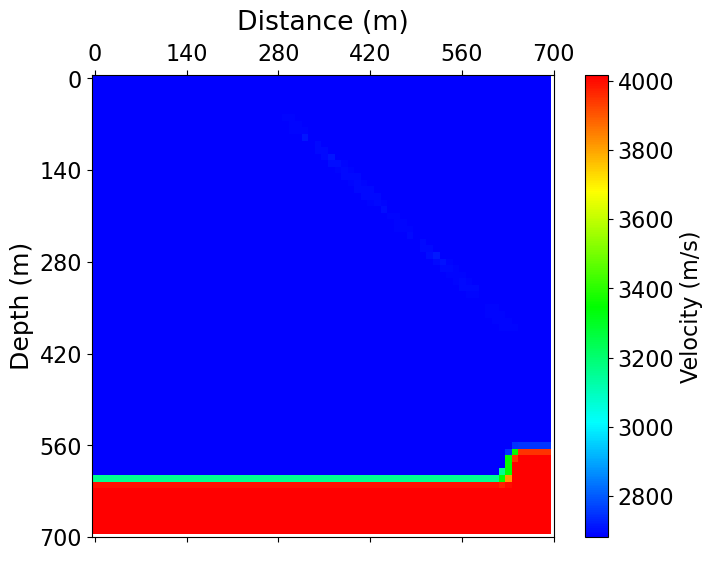

In [80]:
plot_velocity_model(velocity_map_ffa, sample_ffa, path=f"outputs/FlatFault_A/model_plot_sample{sample_ffa}.png")

Sismograma salvo em: outputs/FlatFault_A/seismic_plot_sample0.png


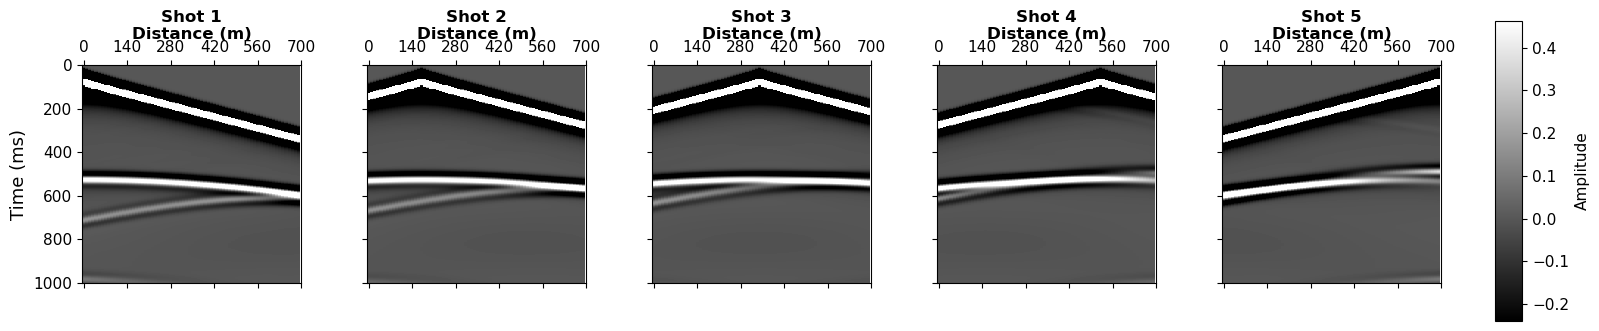

In [81]:
plot_5_shots(seismic_data_ffa, sample=0, path=f"outputs/FlatFault_A/seismic_plot_sample{sample_ffa}.png")

## Replicando com o Deepwave

In [82]:
# --- Parâmetros Sísmicos (Baseados no seu JSON) ---
dx = 10.0          # Espaçamento da grade (m) -> Alterado de 4.0 para 10.0 (conforme 'dx': 10)
dt = 1e-3          # Intervalo de tempo (s) -> Alterado para 0.001 (conforme 'dt': 1e-3)
nt = 1000          # Número de passos de tempo -> Alterado para 1000 (conforme 'nt': 1000)
peak_freq = 15     # Frequência central (Hz) -> Alterado para 15 (conforme 'f': 15)
peak_time = 1.0 / peak_freq  # Tempo de pico padrão para a Ricker (1/15 = 0.066s)
num_dims = 2       # Modelagem 2D

# --- Geometria de Aquisição (Baseados no seu JSON) ---
num_shots = 5                 # Número de fontes/tiros -> Alterado de 3 para 5 (conforme 'ns': 5)
num_sources_per_shot = 1      # 1 fonte por tiro
num_receivers_per_shot = 70   # Número de receptores -> Alterado de 384 para 70 (conforme 'ng': 70)

# Espaçamentos físicos em metros
source_spacing_m = 120        # Distância em metros entre os tiros (ajuste conforme seu modelo)
receiver_spacing_m = 10       # Distância em metros entre receptores (geralmente igual ao dx)
first_source_m = 100          # Posição X em metros da primeira fonte
first_receiver_m = 0          # Posição X em metros do primeiro receptor

# Profundidades em metros (Convertidas de 'sz': 10 e 'gz': 10 da grade -> 10 * 10m = 100m)
source_depth_m = 100          
receiver_depth_m = 100        

# --- Conversão de Metros para Índices da Grade (Essencial para o Deepwave) ---
source_spacing = int(source_spacing_m / dx)
receiver_spacing = int(receiver_spacing_m / dx)
first_source = int(first_source_m / dx)
first_receiver = int(first_receiver_m / dx)
source_depth = int(source_depth_m / dx)
receiver_depth = int(receiver_depth_m / dx)


# --- Criação dos Tensores de Posição ---

# source_locations (Dimensões: [num_shots, num_sources_per_shot, num_dims])
source_locations = torch.zeros(num_shots, num_sources_per_shot, num_dims,
                               dtype=torch.long, device=device)
source_locations[..., 1] = source_depth  # Define a profundidade Z fixa
# Calcula a posição X de cada tiro ao longo da grade
source_locations[:, 0, 0] = torch.arange(num_shots, device=device) * source_spacing + first_source

# receiver_locations (Dimensões: [num_shots, num_receivers_per_shot, num_dims])
receiver_locations = torch.zeros(num_shots, num_receivers_per_shot, num_dims,
                                 dtype=torch.long, device=device)
receiver_locations[..., 1] = receiver_depth  # Define a profundidade Z fixa
# Calcula a posição X de todos os receptores para todos os tiros
receiver_x = torch.arange(num_receivers_per_shot, device=device) * receiver_spacing + first_receiver
receiver_locations[:, :, 0] = receiver_x.repeat(num_shots, 1)


# --- Criando a Amplitude da Fonte (Ondaleta Ricker) ---

# O Deepwave gera a Ricker com formato [nt]. Precisamos expandir para [num_shots, num_sources, nt]
ricker_wavelet = deepwave.wavelets.ricker(peak_freq, nt, dt, peak_time)
source_amplitudes = (ricker_wavelet
                     .repeat(num_shots, num_sources_per_shot, 1)
                     .to(device))

In [83]:
vel_ffa = velocity_map_ffa[sample, 0, :, :]
v_ffa = torch.tensor(vel_ffa, dtype=torch.float32).T

In [84]:
# --- 8. Propagação da Onda (Forward Modeling) ---
out_ffa = deepwave.scalar(
    v_ffa, 
    grid_spacing=dx,
    dt=dt,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    accuracy=4,
    pml_freq=peak_freq
)

# O dado sísmico gravado estará em out_ffa[-1]
data_ffa = out_ffa[-1]
print(f"Shape do dado simulado: {data_ffa.shape}")

Shape do dado simulado: torch.Size([5, 70, 1000])


In [85]:
# save modeled data to file
np.save(f'outputs/FlatFault_A/seismic_data_simulated_sample{sample}.npy', data_ffa.cpu().numpy())

Sismograma salvo em: outputs/FlatFault_A/seismic_plot_simulated_sample0.png


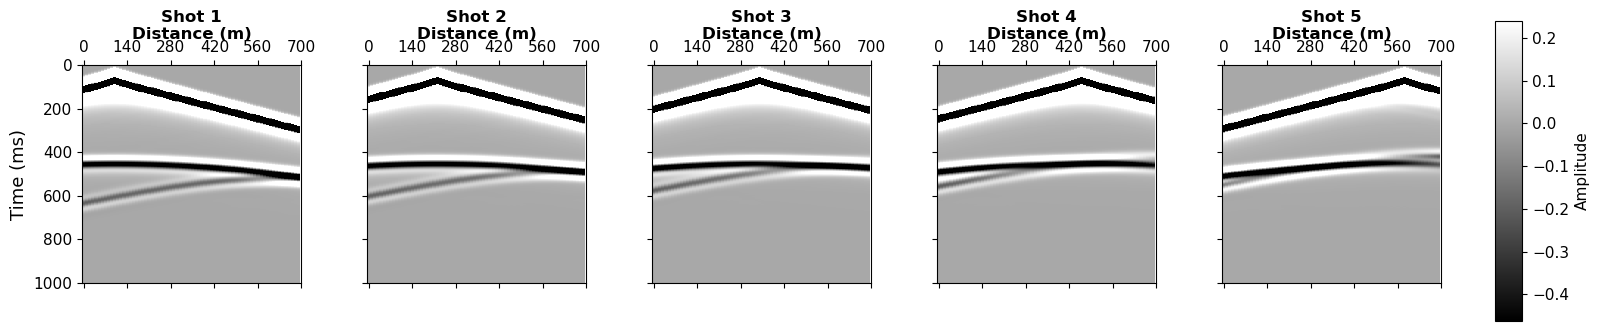

In [86]:
data_ffa = data_ffa.permute(0, 2, 1).cpu().numpy()
plot_5_shots(data_ffa, sample=0, path=f"outputs/FlatFault_A/seismic_plot_simulated_sample{sample}.png")

## Métricas de comparação

In [87]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

# --- 1. Carregar os Dados ---
# Substitua pelos caminhos exatos dos seus arquivos
caminho_simulado = f"outputs/FlatFault_A/seismic_data_simulated_sample{sample}.npy"
caminho_original = "openfwi-examples/FlatFault_A/seis2_1_2.npy"

dado_simulado_bruto = np.load(caminho_simulado)
dado_original_bruto = np.load(caminho_original)

print(f"Shape inicial simulado: {dado_simulado_bruto.shape}")
print(f"Shape inicial original: {dado_original_bruto.shape}")

Shape inicial simulado: (5, 70, 1000)
Shape inicial original: (500, 5, 1000, 70)


In [88]:
# --- 2. Ajustar e Isolar o Sample 0 ---
# Garante que ambos fiquem no mesmo formato (5 tiros, 1000 amostras, 70 receptores)
# Se o dado simulado veio direto do Deepwave, o shape original é (5, 70, 1000)
if dado_simulado_bruto.ndim == 3 and dado_simulado_bruto.shape == (5, 70, 1000):
    # Transpõe para (5, 1000, 70)
    dado_simulado = np.transpose(dado_simulado_bruto, (0, 2, 1))
else:
    dado_simulado = dado_simulado_bruto[sample] if dado_simulado_bruto.ndim == 4 else dado_simulado_bruto

# Isola o exemplo 0 do original (se ele for o dataset completo de shape 500, 5, 1000, 70)
dado_original = dado_original_bruto[sample] if dado_original_bruto.ndim == 4 else dado_original_bruto

print(f"\nShape ajustado simulado: {dado_simulado.shape}")
print(f"Shape ajustado original: {dado_original.shape}")

# --- 3. Função Auxiliar de Normalização ---
def normalizar_max(matriz):
    max_abs = np.max(np.abs(matriz))
    return matriz / max_abs if max_abs > 0 else matriz


Shape ajustado simulado: (5, 1000, 70)
Shape ajustado original: (5, 1000, 70)


In [89]:
# --- 4. Loop pelos 5 Tiros (Shots) para Calcular as Métricas ---
print("\n" + "="*50)
print("       MÉTRICAS QUANTITATIVAS POR TIRO")
print("="*50)

lista_mse, lista_mae, lista_ssim, lista_corr = [], [], [], []

for ishot in range(5):
    # Isolando as matrizes 2D (1000, 70) do tiro atual
    shot_orig = normalizar_max(dado_original[ishot])
    shot_simu = normalizar_max(dado_simulado[ishot])
    
    # A. Métricas Estatísticas (MSE e MAE)
    mse = mean_squared_error(shot_orig, shot_simu)
    mae = mean_absolute_error(shot_orig, shot_simu)
    
    # B. Similaridade Estrutural (SSIM) - Escala [-1, 1] pós-normalização tem range de 2.0
    indice_ssim = ssim(shot_orig, shot_simu, data_range=2.0)
    
    # C. Correlação Cruzada Média Traço a Traço
    correlacoes_tracos = []
    num_receptores = shot_orig.shape[1] # 70
    for r in range(num_receptores):
        traco_orig = shot_orig[:, r]
        traco_simu = shot_simu[:, r]
        corr = np.corrcoef(traco_orig, traco_simu)[0, 1]
        if not np.isnan(corr):
            correlacoes_tracos.append(corr)
    corr_media = np.mean(correlacoes_tracos)
    
    # Armazenando para as médias globais
    lista_mse.append(mse)
    lista_mae.append(mae)
    lista_ssim.append(indice_ssim)
    lista_corr.append(corr_media)
    
    # Print por tiro
    print(f"Shot {ishot+1}:")
    print(f"  - MSE:       {mse:.6f} (Próximo de 0 é ideal)")
    print(f"  - MAE:       {mae:.6f} (Próximo de 0 é ideal)")
    print(f"  - SSIM:      {indice_ssim:.4f} (Próximo de 1 é ideal)")
    print(f"  - Correlação:  {corr_media:.4f} (Próximo de 1 é ideal)")
    print("-" * 30)


       MÉTRICAS QUANTITATIVAS POR TIRO
Shot 1:
  - MSE:       0.002010 (Próximo de 0 é ideal)
  - MAE:       0.012307 (Próximo de 0 é ideal)
  - SSIM:      0.8699 (Próximo de 1 é ideal)
  - Correlação:  0.2907 (Próximo de 1 é ideal)
------------------------------
Shot 2:
  - MSE:       0.002990 (Próximo de 0 é ideal)
  - MAE:       0.014381 (Próximo de 0 é ideal)
  - SSIM:      0.8429 (Próximo de 1 é ideal)
  - Correlação:  0.1456 (Próximo de 1 é ideal)
------------------------------
Shot 3:
  - MSE:       0.005642 (Próximo de 0 é ideal)
  - MAE:       0.018549 (Próximo de 0 é ideal)
  - SSIM:      0.8397 (Próximo de 1 é ideal)
  - Correlação:  -0.8681 (Próximo de 1 é ideal)
------------------------------
Shot 4:
  - MSE:       0.002595 (Próximo de 0 é ideal)
  - MAE:       0.013499 (Próximo de 0 é ideal)
  - SSIM:      0.8519 (Próximo de 1 é ideal)
  - Correlação:  0.3011 (Próximo de 1 é ideal)
------------------------------
Shot 5:
  - MSE:       0.002122 (Próximo de 0 é ideal)
  - 

In [90]:
# --- 5. Relatório Geral ---
print("\n" + "="*50)
print("              RESUMO DA COMPARAÇÃO")
print("="*50)
print(f"MSE Médio:       {np.mean(lista_mse):.6f}")
print(f"MAE Médio:       {np.mean(lista_mae):.6f}")
print(f"SSIM Médio:      {np.mean(lista_ssim):.4f}")
print(f"Correlação Média: {np.mean(lista_corr):.4f}")
print("="*50)


              RESUMO DA COMPARAÇÃO
MSE Médio:       0.003072
MAE Médio:       0.014303
SSIM Médio:      0.8528
Correlação Média: 0.0138
